# WM-811K Wafer Defect Classification — CNN Pipeline

**Goal:** Train a CNN to classify wafer maps into 9 classes (8 defect types + "none").  
**Principles:** No data leakage · Stratified splits · Augmentation on train only · Early stopping · Class-weighted loss.

## 1. Imports & Configuration

In [53]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import LabelEncoder

@dataclass
class CFG:
    seed: int = 42
    batch_size: int = 64
    lr: float = 1e-3
    max_epochs: int = 100
    es_patience: int = 10      # early stopping patience
    lr_patience: int = 5       # ReduceLROnPlateau patience
    lr_factor: float = 0.5
    val_frac: float = 0.20
    num_workers: int = 2
    checkpoint: str = '../best_model.pt'
    figures_dir: str = '../figures'
    tables_dir: str = '../tables'
    # Dev mode: True for CPU/laptop, False for full GPU run
    dev_mode: bool = True
    dev_train_size: int = 4000
    dev_val_size: int = 1000
    dev_test_size: int = 2000

cfg = CFG()

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(cfg.seed)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
Path(cfg.figures_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.tables_dir).mkdir(parents=True, exist_ok=True)

Using device: cpu


## 2. Data Loading & Preparation

We reuse the unpacking pattern from the EDA notebook to unpack the nested arrays in `lotName`, `trainTestLabel`, and `failureType`.

In [54]:
df = pd.read_pickle('../data/LSWMD.pkl')

# Fix typo from original dataset
df.rename(columns={'trianTestLabel': 'trainTestLabel'}, inplace=True)

def unpack(x):
    arr = np.asarray(x)
    if arr.ndim == 0 or arr.size == 0:
        return None
    return arr.flat[0]
for col in ['lotName', 'trainTestLabel', 'failureType']:
    df[col] = df[col].apply(unpack)

# Keep only labeled rows with a known failure type
labeled = df[df['trainTestLabel'].notna() & df['failureType'].notna()].copy()
print(f'Labeled rows before shape filter: {len(labeled):,}')

# Filter to the most common wafer map shape -- different lots can produce
# maps of different dimensions, and np.stack requires uniform shapes
shapes = labeled['waferMap'].apply(lambda w: np.asarray(w).shape)
target_shape = shapes.mode()[0]
labeled = labeled[shapes.apply(lambda x: x == target_shape)].copy()
print(f'Target shape: {target_shape}  --  labeled rows after shape filter: {len(labeled):,}')
print(labeled['failureType'].value_counts())

Labeled rows before shape filter: 172,950
Target shape: (25, 27)  --  labeled rows after shape filter: 18,781
failureType
none         15881
Center        2251
Edge-Loc       355
Loc            172
Random          53
Edge-Ring       25
Scratch         23
Near-full       21
Name: count, dtype: int64


In [55]:
# Encode failure type to integer labels — deterministic alphabetical order
le = LabelEncoder()
labeled['label'] = le.fit_transform(labeled['failureType'])
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)
print(f'Classes ({N_CLASSES}):', CLASS_NAMES)

Classes (8): [np.str_('Center'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]


### Class distribution

Visualising imbalance before the split — this informs our choice of class-weighted loss.

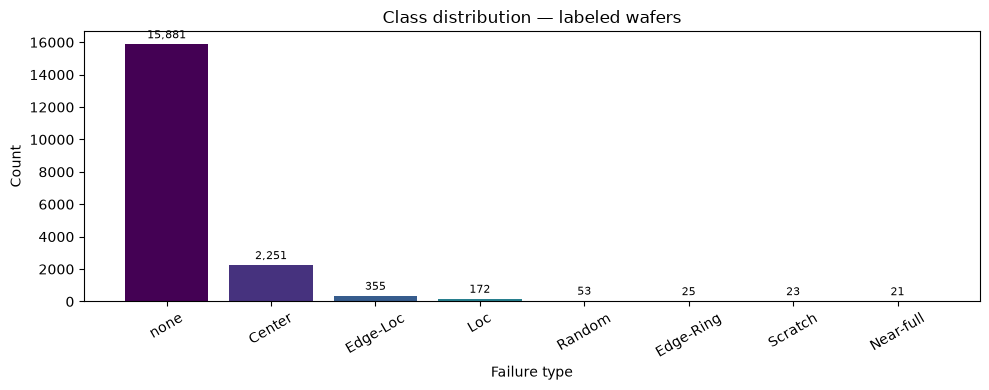

In [56]:
counts = labeled['failureType'].value_counts().sort_values(ascending=False)

colors = plt.colormaps['viridis'](
    [i / (len(counts) - 1) for i in range(len(counts))]
)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(counts.index, counts.values, color=colors)
ax.set_title('Class distribution — labeled wafers')
ax.set_xlabel('Failure type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/class_distribution.png', dpi=150)
plt.show()


## 3. Train / Val / Test Split (no leakage)

The dataset ships with a `trainTestLabel` column. We use it as the primary split.  
Val is carved from the training pool using a stratified shuffle — every class is represented proportionally.

In [57]:
train_pool = labeled[labeled['trainTestLabel'] == 'Training'].copy()
test_df    = labeled[labeled['trainTestLabel'] == 'Test'].copy()

sss = StratifiedShuffleSplit(n_splits=1, test_size=cfg.val_frac, random_state=cfg.seed)
train_idx, val_idx = next(sss.split(train_pool, train_pool['label']))

train_df = train_pool.iloc[train_idx].copy()
val_df   = train_pool.iloc[val_idx].copy()

print(f'Train : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')
print(f'Test  : {len(test_df):,}')

Train : 12,547
Val   : 3,137
Test  : 3,097


In [58]:
if cfg.dev_mode:
    def stratified_sample(df, n, seed):
        if len(df) <= n:
            return df
        # Stratify by label so class proportions mirror the full dataset
        sss = StratifiedShuffleSplit(n_splits=1, test_size=n, random_state=seed)
        _, idx = next(sss.split(df, df['label']))
        return df.iloc[idx].copy()

    train_df = stratified_sample(train_df, cfg.dev_train_size, cfg.seed)
    val_df   = stratified_sample(val_df,   cfg.dev_val_size,   cfg.seed)
    test_df  = stratified_sample(test_df,  cfg.dev_test_size,  cfg.seed)
    print(f'DEV MODE  train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')
    print('Class distribution in dev train set:')
    print(train_df['failureType'].value_counts())
else:
    print(f'FULL MODE  train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')

DEV MODE  train: 4,000  val: 1,000  test: 2,000
Class distribution in dev train set:
failureType
none         3317
Center        566
Edge-Loc       69
Loc            25
Random         11
Edge-Ring       5
Near-full       4
Scratch         3
Name: count, dtype: int64


In [59]:
# Compute mean and std from TRAINING pixels only — no test/val statistics used
train_maps = np.stack([np.asarray(w, dtype=np.float32) for w in train_df['waferMap']])
PIXEL_MEAN = float(train_maps.mean())
PIXEL_STD  = float(train_maps.std()) + 1e-8  # guard against zero std
print(f'Training pixel mean: {PIXEL_MEAN:.4f}, std: {PIXEL_STD:.4f}')

Training pixel mean: 0.9255, std: 0.6257


## 4. PyTorch Dataset & Transforms

Augmentations applied **only** to the training split.  
All splits share the same normalization (computed from training data).

In [60]:
class WaferMapDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.maps   = [np.asarray(w, dtype=np.float32) for w in dataframe['waferMap']]
        self.labels = dataframe['label'].values
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Shape: (H, W) → (1, H, W)
        img = torch.from_numpy(self.maps[idx]).unsqueeze(0)
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


normalize = T.Normalize(mean=[PIXEL_MEAN], std=[PIXEL_STD])

def random_rot90(img):
    # 0 or 180 degrees only — 90/270 change H and W on non-square maps,
    # causing shape mismatch when DataLoader collates the batch
    k = torch.randint(0, 2, (1,)).item() * 2  # 0 or 2
    return torch.rot90(img, k, dims=[-2, -1])

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.Lambda(random_rot90),
    normalize,
])

eval_transform = T.Compose([normalize])

train_ds = WaferMapDataset(train_df, transform=train_transform)
val_ds   = WaferMapDataset(val_df,   transform=eval_transform)
test_ds  = WaferMapDataset(test_df,  transform=eval_transform)

print(f'Dataset sizes — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}')

Dataset sizes — train: 4000, val: 1000, test: 2000


## 5. Class Weights & DataLoaders

In [61]:
# Inverse-frequency weights — computed from training set only
label_counts = np.bincount(train_df['label'].values, minlength=N_CLASSES).astype(float)
class_weights = torch.tensor(
    len(train_df) / (N_CLASSES * label_counts), dtype=torch.float32
).to(DEVICE)

print('Class weights:')
for name, w in zip(CLASS_NAMES, class_weights.cpu().numpy()):
    print(f'  {name:<12} {w:.3f}')

Class weights:
  Center       0.883
  Edge-Loc     7.246
  Edge-Ring    100.000
  Loc          20.000
  Near-full    125.000
  Random       45.455
  Scratch      166.667
  none         0.151


In [62]:
_pin     = DEVICE.type == 'cuda'
_workers = cfg.num_workers if DEVICE.type == 'cuda' else 0

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=_workers, pin_memory=_pin)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=_workers, pin_memory=_pin)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False,
                          num_workers=_workers, pin_memory=_pin)

## 6. CNN Architecture

Three conv blocks halve spatial dimensions at each stage.  
Input `(1, 45, 48)` → `(32, 22, 24)` → `(64, 11, 12)` → `(128, 5, 6)` → flatten 3,840 → FC256 → FC9.

In [63]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
    )

class WaferCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(1, 32),
            conv_block(32, 64),
            conv_block(64, 128),
        )
        # Compute flattened size dynamically — safe against rounding in MaxPool
        with torch.no_grad():
            dummy = torch.zeros(1, 1, *target_shape)
            flat_size = self.features(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = WaferCNN(N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

WaferCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding

## 7. Loss, Optimizer, Scheduler & Early Stopping

In [64]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=cfg.lr_patience, factor=cfg.lr_factor
)

class EarlyStopping:
    def __init__(self, patience, checkpoint_path):
        self.patience = patience
        self.path = checkpoint_path
        self.best_loss = float('inf')
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early_stop = EarlyStopping(cfg.es_patience, cfg.checkpoint)

## 8. Training Loop

In [65]:
def run_epoch(loader, model, criterion, optimizer=None):
    """One forward pass over loader. Pass optimizer=None for eval mode."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            total += len(labels)

    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train Acc":>10}  {"Val Loss":>10}  {"Val Acc":>10}  {"LR":>8}')
print('-' * 65)

for epoch in range(1, cfg.max_epochs + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(val_loader,   model, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>10.4f}  {vl_loss:>10.4f}  {vl_acc:>10.4f}  {current_lr:>8.2e}')

    scheduler.step(vl_loss)
    early_stop(vl_loss, model)
    if early_stop.stop:
        print(f'\nEarly stopping at epoch {epoch}. Best val loss: {early_stop.best_loss:.4f}')
        break

print('Training complete.')

 Epoch  Train Loss   Train Acc    Val Loss     Val Acc        LR
-----------------------------------------------------------------
     1      1.7440      0.7835      1.3366      0.9510  1.00e-03
     2      1.0462      0.8895      3.2981      0.8760  1.00e-03
     3      0.9913      0.8718      0.7842      0.9480  1.00e-03
     4      0.6595      0.8918      1.2114      0.3030  1.00e-03
     5      0.6320      0.9120      1.2502      0.7630  1.00e-03
     6      0.5786      0.9110      0.8887      0.6710  1.00e-03
     7      0.5209      0.9273      1.2040      0.4050  1.00e-03
     8      0.6780      0.9175      0.7054      0.9320  1.00e-03
     9      0.5607      0.9173      0.8650      0.9310  1.00e-03
    10      0.5828      0.8700      0.8330      0.9100  1.00e-03
    11      0.3371      0.9435      0.7336      0.8330  1.00e-03
    12      0.3400      0.9227      0.9201      0.9810  1.00e-03
    13      0.2757      0.9580      0.9474      0.9810  1.00e-03
    14      0.1518      

## 9. Training Curves

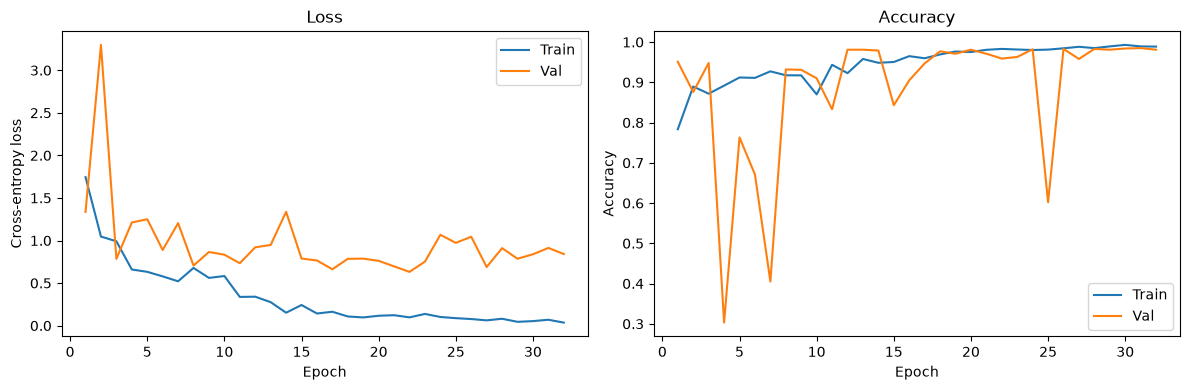

In [66]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, history['train_loss'], label='Train')
ax1.plot(epochs_ran, history['val_loss'],   label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.legend()

ax2.plot(epochs_ran, history['train_acc'], label='Train')
ax2.plot(epochs_ran, history['val_acc'],   label='Val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/training_curves.png', dpi=150)
plt.show()

## 10. Test Set Evaluation

Load the best checkpoint saved by EarlyStopping. Test set is touched **only here**.

In [67]:
model.load_state_dict(torch.load(cfg.checkpoint, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('=== Test Set Results ===')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

=== Test Set Results ===
              precision    recall  f1-score   support

      Center     0.6667    0.4211    0.5161        19
    Edge-Loc     0.4265    0.5273    0.4715        55
   Edge-Ring     0.0000    0.0000    0.0000         3
         Loc     0.6364    0.2857    0.3944        49
   Near-full     0.6667    1.0000    0.8000         2
      Random     0.6000    0.8571    0.7059         7
     Scratch     1.0000    0.1250    0.2222         8
        none     0.9665    0.9801    0.9733      1857

    accuracy                         0.9400      2000
   macro avg     0.6203    0.5245    0.5104      2000
weighted avg     0.9379    0.9400    0.9354      2000



## 11. Confusion Matrix

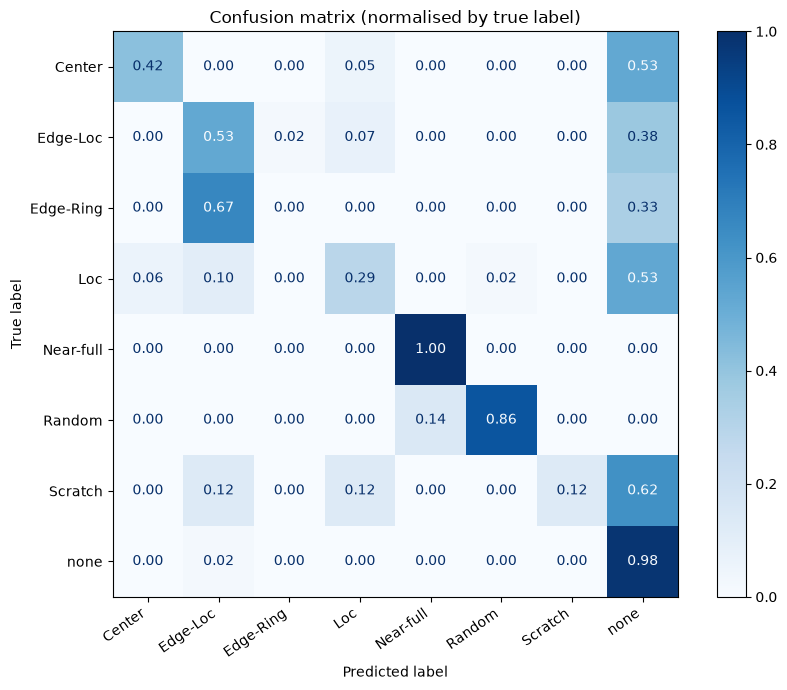

In [68]:
cm = confusion_matrix(all_labels, all_preds, normalize='true')

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('Confusion matrix (normalised by true label)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/confusion_matrix.png', dpi=150)
plt.show()

## 12. Baseline Results

Lock in all baseline metrics **before** any architecture or augmentation changes. This section is the reference point every subsequent experiment is measured against.

In [69]:
def evaluate_model(model, loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    summary = {
        'accuracy':    report['accuracy'],
        'macro_f1':    report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
    return all_preds, all_labels, report, summary


def report_to_markdown(report):
    """Convert sklearn classification_report dict to a markdown table via pandas."""
    df = pd.DataFrame(report).T.round(4)
    return df.to_markdown()


def comparison_to_markdown(rows):
    """Convert a list of result dicts to a markdown table via pandas."""
    return pd.DataFrame(rows).rename(columns={
        'run': 'Run', 'accuracy': 'Accuracy',
        'macro_f1': 'Macro F1', 'weighted_f1': 'Weighted F1', 'epochs': 'Epochs'
    }).to_markdown(index=False)


CMAP_WM = plt.colormaps['RdYlGn_r'].resampled(3)


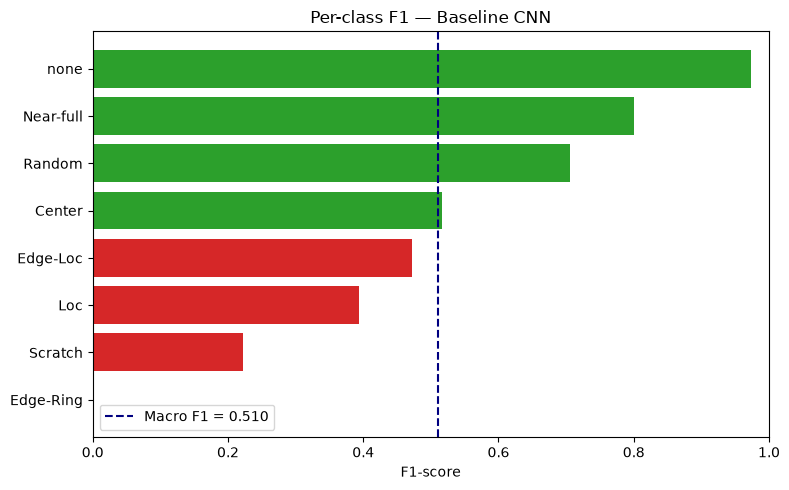

In [70]:
# Load best baseline checkpoint and run inference on test set
model.load_state_dict(torch.load(cfg.checkpoint, map_location=DEVICE, weights_only=True))
baseline_preds, baseline_labels, baseline_report, baseline_summary = evaluate_model(
    model, test_loader, CLASS_NAMES, DEVICE
)
baseline_summary['epochs'] = len(history['train_loss'])

# Per-class F1 horizontal bar chart
f1_scores = {cls: baseline_report[cls]['f1-score'] for cls in CLASS_NAMES}
sorted_cls = sorted(f1_scores, key=f1_scores.get)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#d62728' if f1_scores[c] < 0.5 else '#2ca02c' for c in sorted_cls]
ax.barh(sorted_cls, [f1_scores[c] for c in sorted_cls], color=bar_colors)
ax.set_xlabel('F1-score')
ax.set_title('Per-class F1 — Baseline CNN')
ax.set_xlim(0, 1)
ax.axvline(baseline_summary['macro_f1'], color='navy', linestyle='--',
           label=f"Macro F1 = {baseline_summary['macro_f1']:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/per_class_f1_baseline.png', dpi=150)
plt.show()

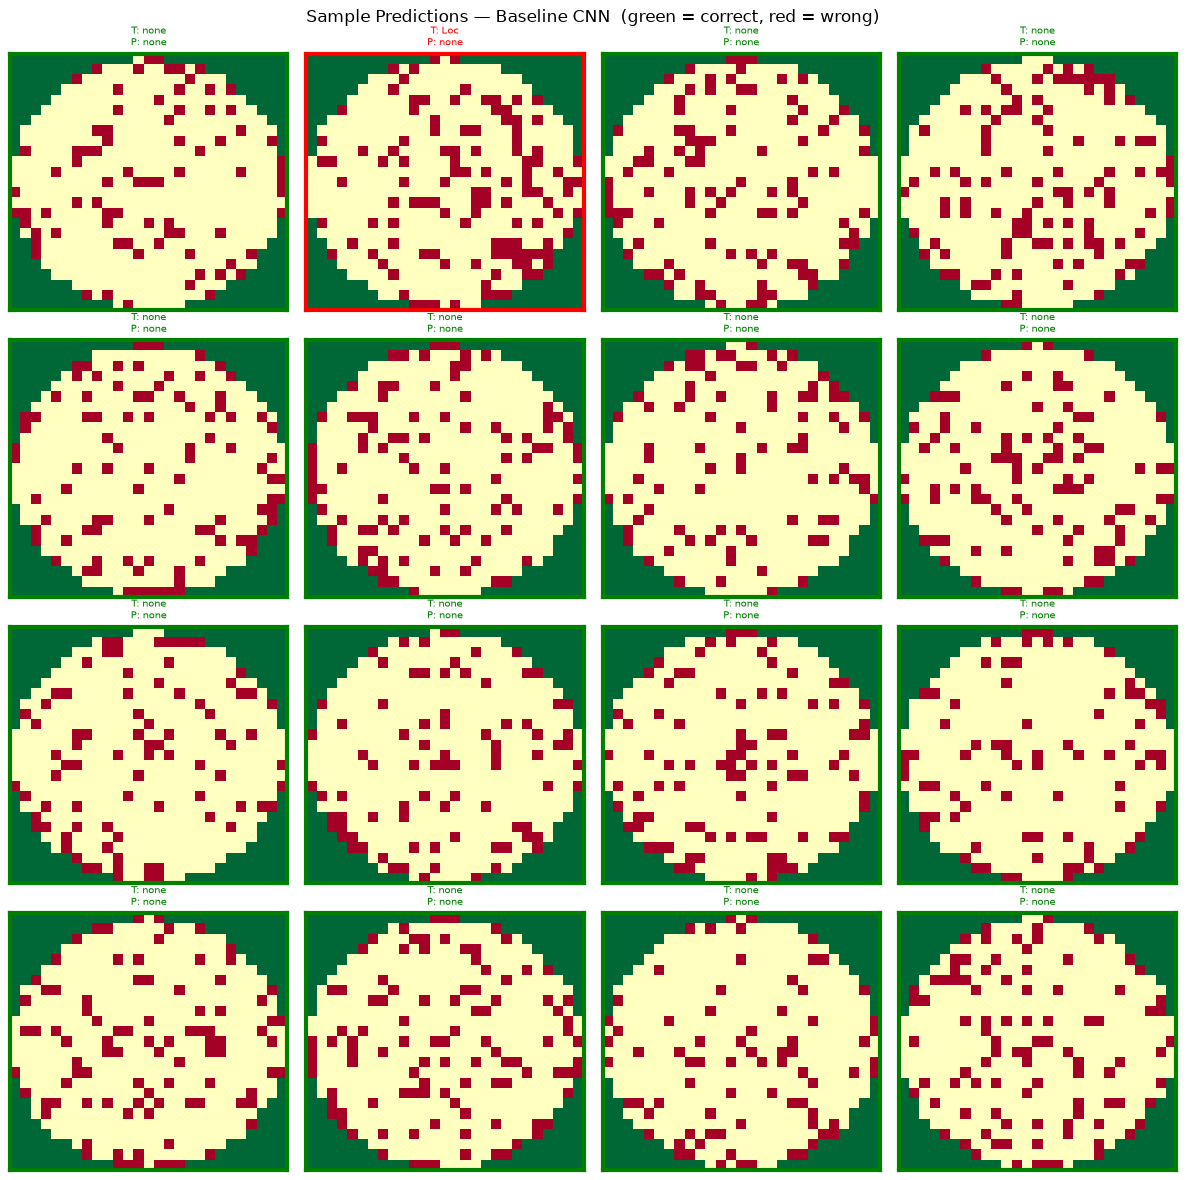

In [71]:
# 4x4 sample predictions grid — green border = correct, red = wrong
rng_sample = np.random.default_rng(cfg.seed)
sample_idx = rng_sample.choice(len(test_ds), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, idx in zip(axes.flatten(), sample_idx):
    img, true_label = test_ds[int(idx)]
    pred_label = int(baseline_preds[idx])
    wmap = img.squeeze().numpy() * PIXEL_STD + PIXEL_MEAN
    ax.imshow(wmap, cmap=CMAP_WM, vmin=0, vmax=2, interpolation='nearest')
    correct = (pred_label == true_label)
    color = 'green' if correct else 'red'
    ax.set_title(f'T: {CLASS_NAMES[true_label]}\nP: {CLASS_NAMES[pred_label]}',
                 fontsize=7, color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

fig.suptitle('Sample Predictions — Baseline CNN  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/sample_predictions_baseline.png', dpi=150)
plt.show()

In [72]:
# Save classification report as markdown
Path(f'{cfg.tables_dir}/classification_report_baseline.md').write_text(
    '# Baseline CNN — Classification Report\n\n' + report_to_markdown(baseline_report) + '\n'
)
print('Saved: tables/classification_report_baseline.md')

# Initialise model comparison table (overwritten fresh each time baseline runs)
comparison_rows = [dict(
    run='Baseline CNN',
    accuracy=baseline_summary['accuracy'],
    macro_f1=baseline_summary['macro_f1'],
    weighted_f1=baseline_summary['weighted_f1'],
    epochs=baseline_summary['epochs'],
)]
Path(f'{cfg.tables_dir}/model_comparison.md').write_text(
    '# Model Comparison\n\n' + comparison_to_markdown(comparison_rows) + '\n'
)
print('Saved: tables/model_comparison.md')
print(f"\nBaseline  Acc: {baseline_summary['accuracy']:.4f}  Macro F1: {baseline_summary['macro_f1']:.4f}  Weighted F1: {baseline_summary['weighted_f1']:.4f}")

Saved: tables/classification_report_baseline.md
Saved: tables/model_comparison.md

Baseline  Acc: 0.9400  Macro F1: 0.5104  Weighted F1: 0.9354


## 13. Experiment: Enhanced Augmentation (RandomErasing)

The baseline is locked in above. We now add `RandomErasing` to the training transform and re-train from scratch.

`RandomErasing` randomly blanks a small rectangular patch of the wafer map at each training step. This forces the model not to over-rely on any single spatial region — useful for distinguishing `Edge-Loc` from `Loc`, which differ primarily by *where* on the wafer the defect cluster appears. It also acts as a regulariser against memorising specific pixel configurations.

Val and test datasets are **unchanged** — only the training augmentation differs.

In [73]:
train_transform_v2 = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.Lambda(random_rot90),
    normalize,
    T.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

train_ds_v2   = WaferMapDataset(train_df, transform=train_transform_v2)
train_loader_v2 = DataLoader(train_ds_v2, batch_size=cfg.batch_size, shuffle=True,
                             num_workers=_workers, pin_memory=_pin)
print('Augmented train dataset ready:', len(train_ds_v2), 'samples')

Augmented train dataset ready: 4000 samples


In [74]:
seed_everything(cfg.seed)
model_v2     = WaferCNN(N_CLASSES).to(DEVICE)
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=cfg.lr)
scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v2, mode='min', patience=cfg.lr_patience, factor=cfg.lr_factor
)
checkpoint_v2  = '../best_model_v2.pt'
early_stop_v2  = EarlyStopping(cfg.es_patience, checkpoint_v2)
history_v2     = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train Acc":>10}  {"Val Loss":>10}  {"Val Acc":>10}  {"LR":>8}')
print('-' * 65)

for epoch in range(1, cfg.max_epochs + 1):
    tr_loss, tr_acc = run_epoch(train_loader_v2, model_v2, criterion, optimizer_v2)
    vl_loss, vl_acc = run_epoch(val_loader,      model_v2, criterion)

    history_v2['train_loss'].append(tr_loss)
    history_v2['val_loss'].append(vl_loss)
    history_v2['train_acc'].append(tr_acc)
    history_v2['val_acc'].append(vl_acc)

    current_lr = optimizer_v2.param_groups[0]['lr']
    print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>10.4f}  {vl_loss:>10.4f}  {vl_acc:>10.4f}  {current_lr:>8.2e}')

    scheduler_v2.step(vl_loss)
    early_stop_v2(vl_loss, model_v2)
    if early_stop_v2.stop:
        print(f'\nEarly stopping at epoch {epoch}. Best val loss: {early_stop_v2.best_loss:.4f}')
        break

print('Training complete.')

 Epoch  Train Loss   Train Acc    Val Loss     Val Acc        LR
-----------------------------------------------------------------
     1      1.7633      0.7452      1.0913      0.9160  1.00e-03
     2      1.1930      0.8525      1.1678      0.9460  1.00e-03
     3      0.8719      0.8900      0.8459      0.9770  1.00e-03
     4      0.7577      0.8908      0.8936      0.8090  1.00e-03
     5      0.7290      0.9123      0.7351      0.8750  1.00e-03
     6      0.6106      0.9290      0.8416      0.6640  1.00e-03
     7      0.6526      0.9147      3.1184      0.0460  1.00e-03
     8      0.6638      0.8752      0.8667      0.9590  1.00e-03
     9      0.5447      0.9035      0.9564      0.9770  1.00e-03
    10      0.5053      0.9235      1.2238      0.9800  1.00e-03
    11      0.5042      0.8998      0.6747      0.9510  1.00e-03
    12      0.3996      0.9323      0.7798      0.9370  1.00e-03
    13      0.4575      0.9265      0.6281      0.8890  1.00e-03
    14      0.4267      

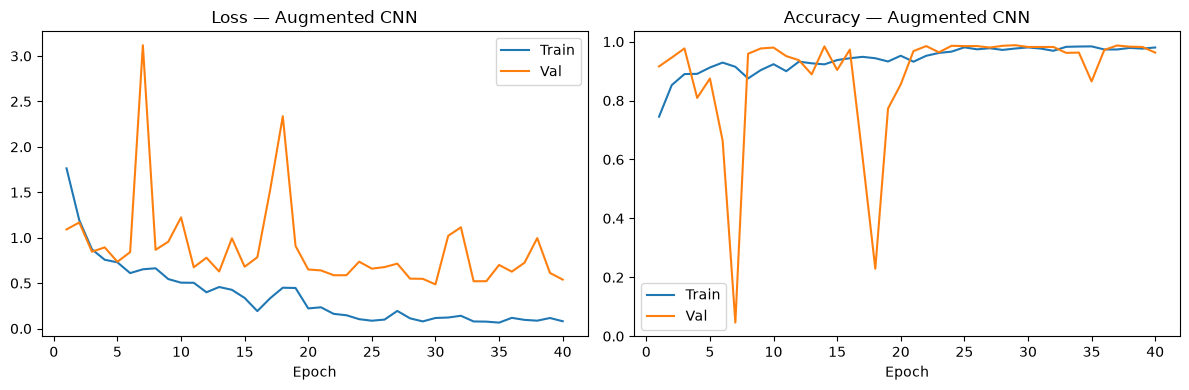

In [75]:
epochs_v2 = range(1, len(history_v2['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_v2, history_v2['train_loss'], label='Train')
ax1.plot(epochs_v2, history_v2['val_loss'],   label='Val')
ax1.set_title('Loss — Augmented CNN'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(epochs_v2, history_v2['train_acc'], label='Train')
ax2.plot(epochs_v2, history_v2['val_acc'],   label='Val')
ax2.set_title('Accuracy — Augmented CNN'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/training_curves_augmented.png', dpi=150)
plt.show()

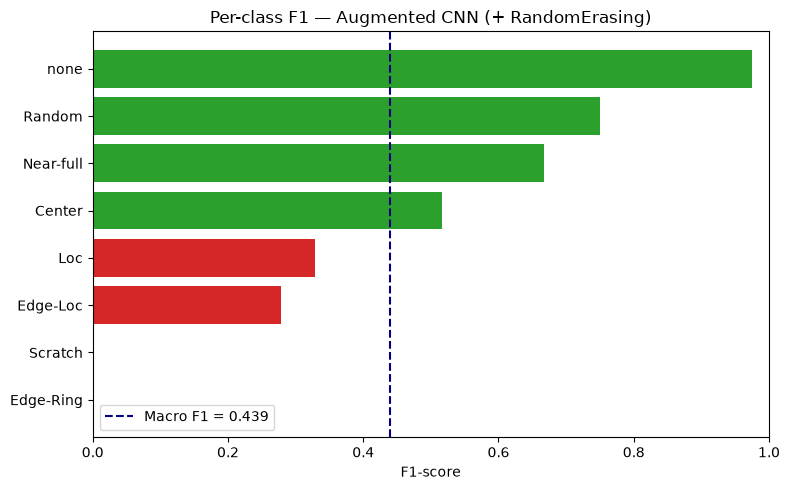

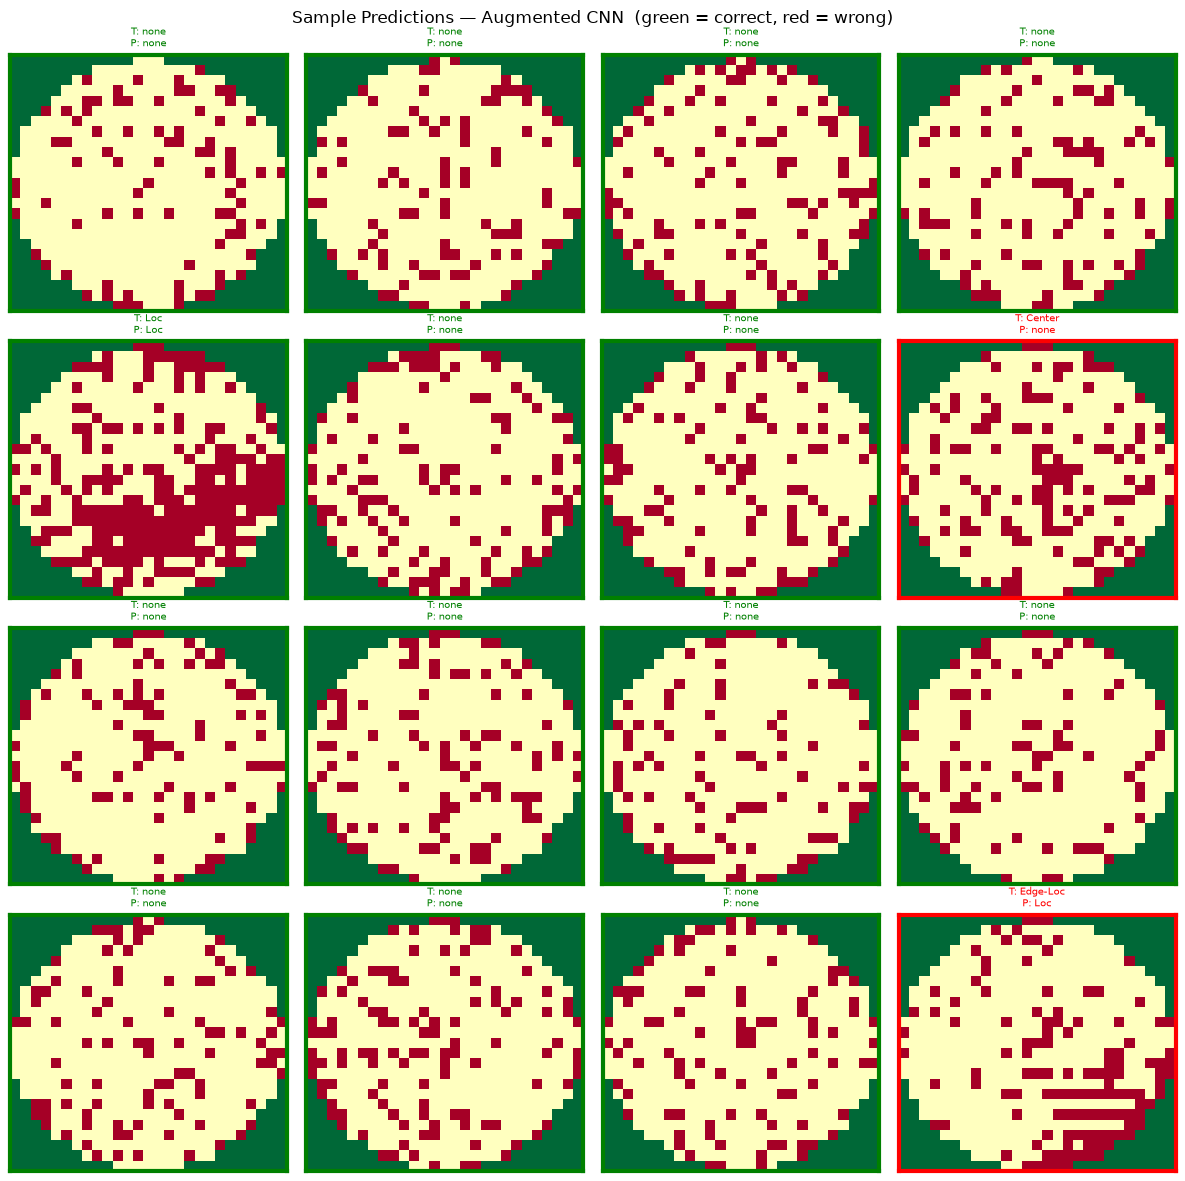

Saved: tables/classification_report_augmented.md
Saved: tables/model_comparison.md

Augmented  Acc: 0.9405  Macro F1: 0.4394  Weighted F1: 0.9291


In [76]:
model_v2.load_state_dict(torch.load(checkpoint_v2, map_location=DEVICE, weights_only=True))
aug_preds, aug_labels, aug_report, aug_summary = evaluate_model(
    model_v2, test_loader, CLASS_NAMES, DEVICE
)
aug_summary['epochs'] = len(history_v2['train_loss'])

# Per-class F1
f1_v2 = {cls: aug_report[cls]['f1-score'] for cls in CLASS_NAMES}
sorted_v2 = sorted(f1_v2, key=f1_v2.get)
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors_v2 = ['#d62728' if f1_v2[c] < 0.5 else '#2ca02c' for c in sorted_v2]
ax.barh(sorted_v2, [f1_v2[c] for c in sorted_v2], color=bar_colors_v2)
ax.set_xlabel('F1-score')
ax.set_title('Per-class F1 — Augmented CNN (+ RandomErasing)')
ax.set_xlim(0, 1)
ax.axvline(aug_summary['macro_f1'], color='navy', linestyle='--',
           label=f"Macro F1 = {aug_summary['macro_f1']:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/per_class_f1_augmented.png', dpi=150)
plt.show()

# Sample predictions
sample_idx_v2 = np.random.default_rng(cfg.seed + 1).choice(len(test_ds), size=16, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, idx in zip(axes.flatten(), sample_idx_v2):
    img, true_label = test_ds[int(idx)]
    pred_label = int(aug_preds[idx])
    wmap = img.squeeze().numpy() * PIXEL_STD + PIXEL_MEAN
    ax.imshow(wmap, cmap=CMAP_WM, vmin=0, vmax=2, interpolation='nearest')
    correct = (pred_label == true_label)
    color = 'green' if correct else 'red'
    ax.set_title(f'T: {CLASS_NAMES[true_label]}\nP: {CLASS_NAMES[pred_label]}', fontsize=7, color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
fig.suptitle('Sample Predictions — Augmented CNN  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/sample_predictions_augmented.png', dpi=150)
plt.show()

# Save tables
Path(f'{cfg.tables_dir}/classification_report_augmented.md').write_text(
    '# Augmented CNN — Classification Report\n\n' + report_to_markdown(aug_report) + '\n'
)
print('Saved: tables/classification_report_augmented.md')

comparison_rows.append(dict(
    run='Augmented CNN (+ RandomErasing)',
    accuracy=aug_summary['accuracy'],
    macro_f1=aug_summary['macro_f1'],
    weighted_f1=aug_summary['weighted_f1'],
    epochs=aug_summary['epochs'],
))
Path(f'{cfg.tables_dir}/model_comparison.md').write_text(
    '# Model Comparison\n\n' + comparison_to_markdown(comparison_rows) + '\n'
)
print('Saved: tables/model_comparison.md')
print(f"\nAugmented  Acc: {aug_summary['accuracy']:.4f}  Macro F1: {aug_summary['macro_f1']:.4f}  Weighted F1: {aug_summary['weighted_f1']:.4f}")

## 14. Model Comparison

Side-by-side view of all experiments. `tables/model_comparison.md` is the persistent record — add more rows as you try new architectures or training strategies, then re-run this cell.

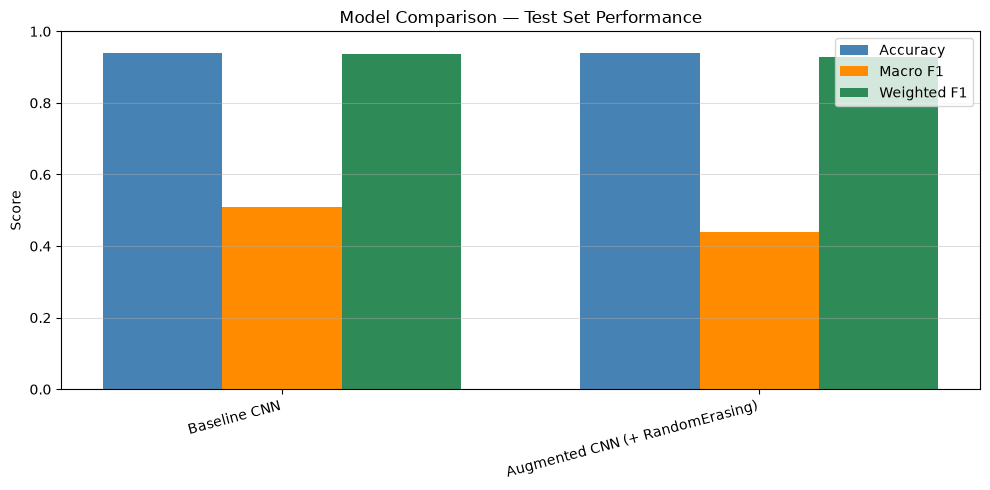


Full comparison table:
# Model Comparison

| Run                             |   Accuracy |   Macro F1 |   Weighted F1 |   Epochs |
|:--------------------------------|-----------:|-----------:|--------------:|---------:|
| Baseline CNN                    |     0.94   |   0.510426 |      0.935366 |       32 |
| Augmented CNN (+ RandomErasing) |     0.9405 |   0.439354 |      0.929051 |       40 |



In [77]:
comp_text = Path(f'{cfg.tables_dir}/model_comparison.md').read_text()
# Parse markdown table rows (skip header and separator lines)
data_lines = [l.strip() for l in comp_text.split('\n')
              if l.startswith('|') and '---' not in l and 'Run' not in l]

runs, accs, macro_f1s, weighted_f1s = [], [], [], []
for line in data_lines:
    parts = [p.strip() for p in line.strip('|').split('|')]
    if len(parts) < 4:
        continue
    runs.append(parts[0])
    accs.append(float(parts[1]))
    macro_f1s.append(float(parts[2]))
    weighted_f1s.append(float(parts[3]))

x = np.arange(len(runs))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, accs,         width, label='Accuracy',    color='steelblue')
ax.bar(x,         macro_f1s,    width, label='Macro F1',    color='darkorange')
ax.bar(x + width, weighted_f1s, width, label='Weighted F1', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Performance')
ax.legend()
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{cfg.figures_dir}/model_comparison.png', dpi=150)
plt.show()

print('\nFull comparison table:')
print(comp_text)